# Previsão de Velocidade do Vento Utilizando Modelo Seq2Seq com Mecanismo de Atenção

Este notebook apresenta um modelo de aprendizado profundo para previsão da velocidade do vento com 6 horas de antecedência no Parque Eólico Delta do Maranhão.

## Objetivos Alcançados
- Desenvolvimento de um modelo preditivo com MAE de 0.16 m/s para previsão de velocidade do vento
- Capacidade de prever tendências e identificar anomalias com 6 horas de antecedência
- Monitoramento efetivo do sensor ws100 (velocidade do vento a 100m de altura)

## Arquitetura do Modelo Implementado
- **Modelo Base**: Sequence-to-Sequence (Seq2Seq) com mecanismo de Atenção
- **Encoder**: LSTM Bidirecional com 512 unidades totais
- **Decoder**: LSTM com 512 unidades e mecanismo de Atenção
- **Entrada**: Série temporal com 72 timesteps (histórico de 12 horas)
- **Saída**: Previsão de 36 timesteps (6 horas à frente)

## Parte do Trabalho de Conclusão de Curso
Este notebook representa a segunda etapa do trabalho, focada no desenvolvimento do modelo preditivo, complementando a Análise Exploratória de Dados (EDA) realizada anteriormente.

In [4]:
# %%
# Importação das bibliotecas necessárias
# Manipulação de dados
import os
import glob
import ctypes
import site
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


import pywt  # Biblioteca para transformacoes wavelet
import keras_tuner as kt
# Pré-processamento
from sklearn.preprocessing import MinMaxScaler

import keras

from keras import backend as K


# Componentes do modelo Seq2Seq com Atenção
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Bidirectional, Dropout, Dense, Concatenate, TimeDistributed, Attention
from tensorflow.keras.layers import (
    Conv1D,
    BatchNormalization,
    Activation,
    Add,
    LayerNormalization,
    Flatten,
    Reshape,
    SpatialDropout1D,
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Métricas de avaliação
from sklearn.metrics import mean_absolute_error, mean_squared_error


# Otimizar alocacao de memoria GPU - reduz fragmentacao
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '1'  # Reduce TensorFlow logging verbosity

# Garante runtime de GPU no Arch Linux (cuSOLVER e libs CUDA via wheel)
def configure_tensorflow_gpu_runtime():
    """Configura paths CUDA do venv e pre-carrega bibliotecas antes do import do TensorFlow."""
    current_ld = os.environ.get('LD_LIBRARY_PATH', '')
    candidate_dirs = []

    for sp in site.getsitepackages():
        candidate_dirs.extend(glob.glob(os.path.join(sp, 'nvidia', '*', 'lib')))

    if 'VIRTUAL_ENV' in os.environ:
        candidate_dirs.extend(
            glob.glob(
                os.path.join(
                    os.environ['VIRTUAL_ENV'],
                    'lib',
                    'python*',
                    'site-packages',
                    'nvidia',
                    '*',
                    'lib',
                )
            )
        )

    valid_dirs = []
    for lib_dir in candidate_dirs:
        if os.path.isdir(lib_dir) and lib_dir not in valid_dirs:
            valid_dirs.append(lib_dir)

    if valid_dirs:
        merged = ':'.join(valid_dirs)
        os.environ['LD_LIBRARY_PATH'] = f"{merged}:{current_ld}" if current_ld else merged

        # Pre-carrega libs CUDA para evitar falha de resolucao dinamica no kernel do VS Code
        preload_libs = [
            'libcudart.so.12',
            'libcublas.so.12',
            'libcudnn.so.9',
            'libcusolver.so.11',
        ]
        for lib_name in preload_libs:
            for lib_dir in valid_dirs:
                lib_path = os.path.join(lib_dir, lib_name)
                if os.path.exists(lib_path):
                    try:
                        ctypes.CDLL(lib_path, mode=ctypes.RTLD_GLOBAL)
                    except OSError:
                        pass
                    break

    return valid_dirs

cuda_lib_dirs = configure_tensorflow_gpu_runtime()
print('CUDA lib dirs found:', len(cuda_lib_dirs))
from tcn import TCN

import tensorflow as tf
print('TensorFlow:', tf.__version__)
print('Python:', os.environ.get('VIRTUAL_ENV', 'sem VIRTUAL_ENV'))
print('GPUs:', tf.config.list_physical_devices('GPU'))

I0000 00:00:1778360386.952128    4403 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


CUDA lib dirs found: 11
TensorFlow: 2.21.0
Python: /home/zino/projects/wind-speed-forescasting/.venv
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Carregamento e Pré-processamento dos Dados

O processo de preparação dos dados inclui:
1. Carregamento dos dados de velocidade do vento previamente processados
2. Normalização usando MinMaxScaler para garantir convergência eficiente do modelo
3. Estruturação das sequências de entrada e saída no formato adequado para o modelo Seq2Seq
4. Divisão dos dados em conjuntos de treino (77%), validação (18%) e teste (5%)

In [5]:
from xml.parsers.expat import model


variables = pd.read_csv('../data/dataset.csv', index_col=0, parse_dates=True)
print("Processed data loaded successfully.")

# Definição das funções de pré-processamento e engenharia de features

# Função de denoising com wavelet
# Esta função aplica técnicas de wavelet para redução de ruído em sinais
def wavelet_denoising(signal, wavelet='sym18', level=2):
    """
    Aplica técnica de denoising wavelet para reduzir o ruído do sinal
    
    Parâmetros:
    signal: array-like - O sinal de entrada a ser processado
    wavelet: str - O tipo de wavelet a ser utilizado (default: 'sym18')
    level: int - O nível de decomposição wavelet (default: 2)
    
    Retorna:
    array-like - Sinal reconstruído após a remoção de ruído
    """
    coeffs = pywt.wavedec(signal, wavelet, mode='periodization', level=level)

    sigma = np.median(np.abs(coeffs[-level])) / 0.6745
    uthresh = sigma * np.sqrt(2 * np.log(len(signal)))

    coeffs[1:] = [pywt.threshold(i, value=uthresh, mode='soft') for i in coeffs[1:]]

    reconstructed_signal = pywt.waverec(coeffs, wavelet, mode='periodization')
    return reconstructed_signal[:len(signal)]

# Lista das colunas que serão submetidas ao processo de denoising
columns_to_denoise = ['ws100', 'wdisp40', 'vertdisp40', 'wdir40', 'cis1', 'humid', 'temp']

# Aplica o denoising em cada coluna e armazena os resultados
for col in columns_to_denoise:
    if col in variables.columns:
        denoised_signal = wavelet_denoising(variables[col].values)
        variables[f'{col}_wavelet'] = denoised_signal
    else:
        raise ValueError(f"A coluna '{col}' não existe no conjunto de dados.")
print("Processed data loaded successfully.")

scaler_ws100 = MinMaxScaler()
scaler_other = MinMaxScaler()

variables_scaled = variables.copy()

ws100_columns = ['ws100_wavelet']
other_columns = variables.columns.drop('ws100_wavelet').tolist()

variables_scaled[ws100_columns] = scaler_ws100.fit_transform(variables[ws100_columns])
variables_scaled[other_columns] = scaler_other.fit_transform(variables[other_columns])

print(f"Shape of scaled data: {variables_scaled.shape}")


input_steps = 72  
output_steps = 36  

def create_sequences(data, input_steps, output_steps, target_col_index):
    """
    Create input and output sequences for the Seq2Seq model using Teacher forcing.
    """
    X_encoder = []
    X_decoder = []
    y_decoder = []
    
    for i in range(len(data) - input_steps - output_steps + 1):
        X_encoder.append(data[i:(i + input_steps)])
        
        decoder_input = np.zeros((output_steps, 1))
        
        decoder_input[0] = data[i + input_steps - 1, target_col_index]
        
        decoder_input[1:] = data[i + input_steps:i + input_steps + output_steps - 1, target_col_index].reshape(-1, 1)
        
        X_decoder.append(decoder_input)
        
        y_decoder.append(data[i + input_steps:i + input_steps + output_steps, target_col_index].reshape(-1, 1))
    
    return np.array(X_encoder), np.array(X_decoder), np.array(y_decoder)

data_array = variables_scaled.values

target_col_index = variables_scaled.columns.get_loc('ws100_wavelet')

X_encoder, X_decoder, y_decoder = create_sequences(data_array, input_steps, output_steps, target_col_index)


print(f"Shape of X_encoder: {X_encoder.shape}")
print(f"Shape of X_decoder: {X_decoder.shape}")
print(f"Shape of y_decoder: {y_decoder.shape}")


print(f"Sample X_encoder[0]: {X_encoder[0]}")
print(f"Sample X_decoder[0]: {X_decoder[0]}")
print(f"Sample y_decoder[0]: {y_decoder[0]}")

train_end = int(X_encoder.shape[0] * 0.77)
val_end = int(X_encoder.shape[0] * 0.95)

X_encoder_train = X_encoder[:train_end]
X_decoder_train = X_decoder[:train_end]
y_decoder_train = y_decoder[:train_end]

X_encoder_val = X_encoder[train_end:val_end]
X_decoder_val = X_decoder[train_end:val_end]
y_decoder_val = y_decoder[train_end:val_end]

X_encoder_test = X_encoder[val_end:]
X_decoder_test = X_decoder[val_end:]
y_decoder_test = y_decoder[val_end:]

print(f"Training X_encoder: {X_encoder_train.shape}, Training X_decoder: {X_decoder_train.shape}, Training y_decoder: {y_decoder_train.shape}")
print(f"Validation X_encoder: {X_encoder_val.shape}, Validation X_decoder: {X_decoder_val.shape}, Validation y_decoder: {y_decoder_val.shape}")
print(f"Test X_encoder: {X_encoder_test.shape}, Test X_decoder: {X_decoder_test.shape}, Test y_decoder: {y_decoder_test.shape}")

num_encoder_features = X_encoder_train.shape[2]
num_decoder_features = 1  

def build_seq2seq_attention_model_factory(input_steps, output_steps, num_encoder_features, num_decoder_features):
    """
    Builds a Seq2Seq factory with attention mechanism using TCN blocks.
    """
    def model_builder(hp):
        K.clear_session()
        learning_rate = hp.Float('learning_rate', min_value=1e-5, max_value=1e-2, sampling='LOG', default = 0.001249176597990083)
        
        encoder_tcn_hp = {}
        encoder_tcn_hp['filters_power'] = hp.Int('filters_power', min_value=4, max_value=9, default=9)
        encoder_tcn_hp['filters'] = 2 ** encoder_tcn_hp['filters_power']
        encoder_tcn_hp['kernel_size'] = hp.Int('encoder_kernel_size', min_value=2, max_value=5, step=1, default=2)
        encoder_tcn_hp['nb_stacks'] = hp.Int('encoder_nb_stacks', min_value=1, max_value=2, step=1, default=1)
        encoder_tcn_hp['dropout_rate'] = hp.Float('encoder_dropout_rate', min_value=0.1, max_value=0.5, step=0.1, default=0.2)
        encoder_tcn_hp['dilation_rate'] = hp.Int('encoder_dilation_rate', min_value=1, max_value=4, step=1, default=3)
        encoder_tcn_hp['dilations'] = [2 ** i for i in range(encoder_tcn_hp['dilation_rate'])]


        decoder_tcn_hp = {}
        decoder_tcn_hp['filters_power'] = encoder_tcn_hp['filters_power']
        decoder_tcn_hp['filters'] = 2 ** decoder_tcn_hp['filters_power']
        decoder_tcn_hp['kernel_size'] = hp.Int('decoder_kernel_size', min_value=2, max_value=5, step=1, default=4)
        decoder_tcn_hp['nb_stacks'] = hp.Int('decoder_nb_stacks', min_value=1, max_value=2, step=1, default=2)
        decoder_tcn_hp['dropout_rate'] = hp.Float('decoder_dropout_rate', min_value=0.1, max_value=0.5, step=0.1, default=0.1)
        decoder_tcn_hp['dilation_rate'] = hp.Int('decoder_dilation_rate', min_value=1, max_value=4, step=1, default=4)
        decoder_tcn_hp['dilations'] = [2 ** i for i in range(decoder_tcn_hp['dilation_rate'])]


        optimizer = Adam(learning_rate=learning_rate)
        
        encoder_inputs = Input(shape=(input_steps, num_encoder_features), name='encoder_inputs')
        encoder_outputs = TCN(
            nb_filters=encoder_tcn_hp['filters'],
            kernel_size=encoder_tcn_hp['kernel_size'],
            nb_stacks=encoder_tcn_hp['nb_stacks'],
            dropout_rate=encoder_tcn_hp['dropout_rate'],
            dilations=encoder_tcn_hp['dilations'],
            return_sequences=True,
            name='encoder_tcn'
        )(encoder_inputs)
        encoder_outputs = Dropout(0.1)(encoder_outputs)
        
        decoder_inputs = Input(shape=(output_steps, num_decoder_features), name='decoder_inputs')
        decoder_outputs = TCN(
            nb_filters=decoder_tcn_hp['filters'],
            kernel_size=decoder_tcn_hp['kernel_size'],
            nb_stacks=decoder_tcn_hp['nb_stacks'],
            dropout_rate=decoder_tcn_hp['dropout_rate'],
            dilations=decoder_tcn_hp['dilations'],
            return_sequences=True,
            name='decoder_tcn'
        )(decoder_inputs)
        decoder_outputs = Dropout(0.1)(decoder_outputs)
        #decoder_outputs = Dense(decoder_tcn_hp['filters'], activation='linear')(decoder_outputs)
        
        attention_layer = Attention(name='attention_layer')
        attention_outputs = attention_layer([decoder_outputs, encoder_outputs])
        
        decoder_combined_context = Concatenate(axis=-1)([decoder_outputs, attention_outputs])
        
        decoder_dense = TimeDistributed(Dense(1, activation='linear'), name='output_layer')
        decoder_outputs_final = decoder_dense(decoder_combined_context)
        
        model = Model([encoder_inputs, decoder_inputs], decoder_outputs_final)
        model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    
        return model
    return model_builder

def build_seq2seq_attention_model_factory_bidir(input_steps, output_steps, num_encoder_features, num_decoder_features):
    """
    Builds a Seq2Seq factory with attention mechanism using TCN blocks.
    """
    def model_builder(hp):
        K.clear_session()
        learning_rate = hp.Float('learning_rate', min_value=1e-5, max_value=1e-2, sampling='LOG', default = 0.007588614903739156)
        
        encoder_tcn_hp = {}
        encoder_tcn_hp['filters_power'] = hp.Int('filters_power', min_value=4, max_value=9, default=6)
        encoder_tcn_hp['filters'] = 2 ** encoder_tcn_hp['filters_power']
        encoder_tcn_hp['kernel_size'] = hp.Int('encoder_kernel_size', min_value=2, max_value=5, step=1, default=2)
        encoder_tcn_hp['nb_stacks'] = hp.Int('encoder_nb_stacks', min_value=1, max_value=2, step=1, default=2)
        encoder_tcn_hp['dropout_rate'] = hp.Float('encoder_dropout_rate', min_value=0.1, max_value=0.5, step=0.1, default=0.2)
        encoder_tcn_hp['dilation_rate'] = hp.Int('encoder_dilation_rate', min_value=1, max_value=4, step=1, default=1)
        encoder_tcn_hp['dilations'] = [2 ** i for i in range(encoder_tcn_hp['dilation_rate'])]


        decoder_tcn_hp = {}
        decoder_tcn_hp['filters_power'] = encoder_tcn_hp['filters_power']
        decoder_tcn_hp['filters'] = 2 ** decoder_tcn_hp['filters_power']
        decoder_tcn_hp['kernel_size'] = hp.Int('decoder_kernel_size', min_value=2, max_value=5, step=1, default=5)
        decoder_tcn_hp['nb_stacks'] = hp.Int('decoder_nb_stacks', min_value=1, max_value=2, step=1, default=1)
        decoder_tcn_hp['dropout_rate'] = hp.Float('decoder_dropout_rate', min_value=0.1, max_value=0.5, step=0.1, default=0.1)
        decoder_tcn_hp['dilation_rate'] = hp.Int('decoder_dilation_rate', min_value=1, max_value=4, step=1, default=2)
        decoder_tcn_hp['dilations'] = [2 ** i for i in range(decoder_tcn_hp['dilation_rate'])]


        optimizer = Adam(learning_rate=learning_rate)
        
        encoder_inputs = Input(shape=(input_steps, num_encoder_features), name='encoder_inputs')
        encoder_outputs = Bidirectional(TCN(
            nb_filters=encoder_tcn_hp['filters'],
            kernel_size=encoder_tcn_hp['kernel_size'],
            nb_stacks=encoder_tcn_hp['nb_stacks'],
            dropout_rate=encoder_tcn_hp['dropout_rate'],
            dilations=encoder_tcn_hp['dilations'],
            return_sequences=True,
            name='encoder_tcn'
        ))(encoder_inputs)
        encoder_outputs = Dropout(0.1)(encoder_outputs)
        
        decoder_inputs = Input(shape=(output_steps, num_decoder_features), name='decoder_inputs')
        decoder_outputs = TCN(
            nb_filters=decoder_tcn_hp['filters']*2,
            kernel_size=decoder_tcn_hp['kernel_size'],
            nb_stacks=decoder_tcn_hp['nb_stacks'],
            dropout_rate=decoder_tcn_hp['dropout_rate'],
            dilations=decoder_tcn_hp['dilations'],
            return_sequences=True,
            name='decoder_tcn'
        )(decoder_inputs)
        decoder_outputs = Dropout(0.1)(decoder_outputs)
        #decoder_outputs = Dense(decoder_tcn_hp['filters'], activation='linear')(decoder_outputs)
        
        attention_layer = Attention(name='attention_layer')
        attention_outputs = attention_layer([decoder_outputs, encoder_outputs])
        
        decoder_combined_context = Concatenate(axis=-1)([decoder_outputs, attention_outputs])
        
        decoder_dense = TimeDistributed(Dense(1, activation='linear'), name='output_layer')
        decoder_outputs_final = decoder_dense(decoder_combined_context)
        
        model = Model([encoder_inputs, decoder_inputs], decoder_outputs_final)
        model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    
        return model
    return model_builder




Processed data loaded successfully.
Processed data loaded successfully.
Shape of scaled data: (7561, 134)
Shape of X_encoder: (7454, 72, 134)
Shape of X_decoder: (7454, 36, 1)
Shape of y_decoder: (7454, 36, 1)
Sample X_encoder[0]: [[0.         0.         0.5        ... 0.24028049 0.49451091 0.61090248]
 [0.         0.         0.5        ... 0.3089705  0.5758299  0.56871989]
 [0.         0.         0.5        ... 0.33843195 0.62509977 0.52887955]
 ...
 [0.         0.         0.53333333 ... 0.38591264 0.79648194 0.40077919]
 [0.         0.         0.53333333 ... 0.42362264 0.78352704 0.40106299]
 [0.         0.         0.53333333 ... 0.4585555  0.76338102 0.40564703]]
Sample X_decoder[0]: [[0.45616311]
 [0.51081932]
 [0.53701196]
 [0.53970205]
 [0.5285529 ]
 [0.5133591 ]
 [0.50134013]
 [0.49746996]
 [0.50630676]
 [0.52963659]
 [0.56384953]
 [0.600675  ]
 [0.62980789]
 [0.64458391]
 [0.64668366]
 [0.6446194 ]
 [0.64880294]
 [0.66551412]
 [0.69259773]
 [0.72124234]
 [0.74115531]
 [0.745413

In [3]:
tuner = kt.Hyperband(build_seq2seq_attention_model_factory(input_steps, output_steps, num_encoder_features, num_decoder_features),
                     objective='val_loss',
                     max_epochs=100,
                     factor=3,
                     hyperband_iterations=3,
                     directory='../models',
                     project_name='tcn_wind_speed_forecasting_valloss_bidirect2')

#tuner.search([X_encoder_train, X_decoder_train], y_decoder_train, epochs=100, validation_data=([X_encoder_val, X_decoder_val], y_decoder_val))
#best_model = tuner.get_best_models()[0]


Reloading Tuner from ../models/tcn_wind_speed_forecasting_valloss_bidirect2/tuner0.json


In [4]:
tuner.results_summary()

Results summary
Results in ../models/tcn_wind_speed_forecasting_valloss_bidirect2
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 0424 summary
Hyperparameters:
learning_rate: 0.007588614903739156
filters_power: 5
encoder_kernel_size: 2
encoder_nb_stacks: 2
encoder_dropout_rate: 0.2
encoder_dilation_rate: 1
decoder_kernel_size: 5
decoder_nb_stacks: 1
decoder_dropout_rate: 0.1
decoder_dilation_rate: 2
tuner/epochs: 100
tuner/initial_epoch: 34
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0416
Score: 4.3776526581496e-05

Trial 0413 summary
Hyperparameters:
learning_rate: 0.0015890354465713434
filters_power: 8
encoder_kernel_size: 2
encoder_nb_stacks: 1
encoder_dropout_rate: 0.4
encoder_dilation_rate: 3
decoder_kernel_size: 4
decoder_nb_stacks: 1
decoder_dropout_rate: 0.1
decoder_dilation_rate: 1
tuner/epochs: 100
tuner/initial_epoch: 34
tuner/bracket: 2
tuner/round: 2
tuner/trial_id: 0409
Score: 5.197116479394026e-05

Trial 0207 summary
Hyperparameters:
learnin

In [5]:
def build_seq2seq_attention_model(input_steps, output_steps, num_encoder_features, num_decoder_features, default=False):
    """
    Builds a Seq2Seq model with attention mechanism using Bidirectional LSTM.
    """
    builder = build_seq2seq_attention_model_factory(input_steps, output_steps, num_encoder_features, num_decoder_features)

    if default or tuner.get_best_hyperparameters() is None:
        model = builder(kt.HyperParameters())  # Use default hyperparameters for final model
    else:
        model = builder(tuner.get_best_hyperparameters()[0])  # Use best hyperparameters from tuning

    return model
def build_seq2seq_attention_model_bidir(input_steps, output_steps, num_encoder_features, num_decoder_features, default=False):
    """
    Builds a Seq2Seq model with attention mechanism using Bidirectional LSTM.
    """
    builder = build_seq2seq_attention_model_factory_bidir(input_steps, output_steps, num_encoder_features, num_decoder_features)

    if default or tuner.get_best_hyperparameters() is None:
        model = builder(kt.HyperParameters())  # Use default hyperparameters for final model
    else:
        model = builder(tuner.get_best_hyperparameters()[0])  # Use best hyperparameters from tuning

    return model
model = build_seq2seq_attention_model(input_steps, output_steps, num_encoder_features, num_decoder_features, default=True)
model_bidir = build_seq2seq_attention_model_bidir(input_steps, output_steps, num_encoder_features, num_decoder_features, default=False)

model.summary()
model_bidir.summary()

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
    ModelCheckpoint('../models/best_model.h5.keras', monitor='val_loss', save_best_only=True)
]
#keras.config.disable_traceback_filtering()
history = model.fit(
    [X_encoder_train, X_decoder_train], y_decoder_train, 
    epochs=100,  
    batch_size=32, 
    validation_data=([X_encoder_val, X_decoder_val], y_decoder_val),
    callbacks=callbacks,
    verbose=1
)

history_bidir = model_bidir.fit(
    [X_encoder_train, X_decoder_train], y_decoder_train, 
    epochs=100,  
    batch_size=32, 
    validation_data=([X_encoder_val, X_decoder_val], y_decoder_val),
    callbacks=callbacks,
    verbose=1
)


I0000 00:00:1776171999.836760  282751 gpu_process_state.cc:208] Using CUDA malloc Async allocator for GPU: 0
I0000 00:00:1776171999.837750  282751 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3544 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ decoder_inputs      │ (None, 36, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_inputs      │ (None, 72, 134)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_tcn (TCN)   │ (None, 36, 512)   │ 15,739,904 │ decoder_inputs[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_tcn (TCN)   │ (None, 72, 512)   │  2,830,848 │ encoder_inputs[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 36, 512)   │          0 │ decoder_tcn[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 72, 512)   │          0 │ encoder_tcn[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_layer     │ (None, 36, 512)   │          0 │ dropout_1[0][0],  │
│ (Attention)         │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 36, 1024)  │          0 │ dropout_1[0][0],  │
│ (Concatenate)       │                   │            │ attention_layer[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_layer        │ (None, 36, 1)     │      1,025 │ concatenate[0][0] │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 18,571,777 (70.85 MB)

 Trainable params: 18,571,777 (70.85 MB)

...

177/180 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.6385 - mae: 0.6528

I0000 00:00:1776172498.065437  284740 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_59754__.74


180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 2.6045 - mae: 0.6462

I0000 00:00:1776172507.148854  284740 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_61466__.8
I0000 00:00:1776172508.621506  284740 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_61466__.8


180/180 ━━━━━━━━━━━━━━━━━━━━ 27s 80ms/step - loss: 0.5973 - mae: 0.2576 - val_loss: 0.0039 - val_mae: 0.0506 - learning_rate: 0.0076
Epoch 2/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0094 - mae: 0.0748 - val_loss: 0.0087 - val_mae: 0.0862 - learning_rate: 0.0076
Epoch 3/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0060 - mae: 0.0592 - val_loss: 0.0019 - val_mae: 0.0373 - learning_rate: 0.0076
Epoch 4/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0046 - mae: 0.0522 - val_loss: 0.0020 - val_mae: 0.0397 - learning_rate: 0.0076
Epoch 5/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0039 - mae: 0.0476 - val_loss: 0.0017 - val_mae: 0.0359 - learning_rate: 0.0076
Epoch 6/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0034 - mae: 0.0442 - val_loss: 0.0022 - val_mae: 0.0422 - learning_rate: 0.0038
Epoch 7/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0031 - mae: 0.0421 - val_loss: 0.0017 - val_mae: 0.0368 - learning_rate: 0.0038
Epoch 8/1

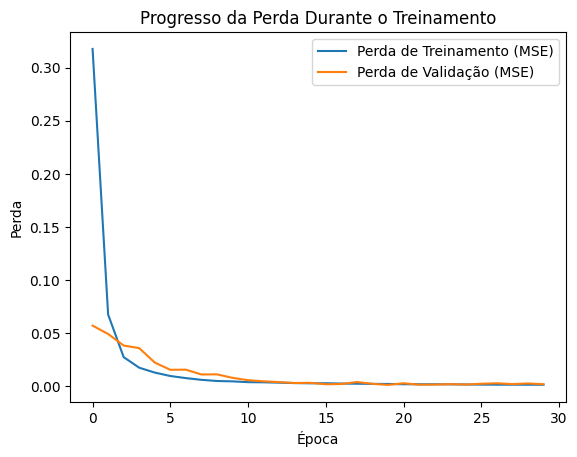

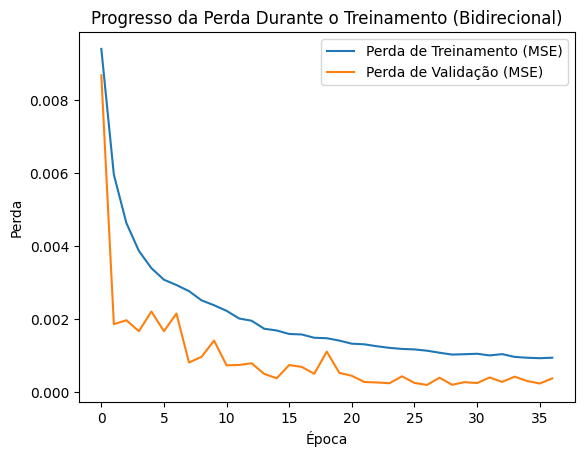

In [6]:

plt.plot(history.history['loss'][1:], label='Perda de Treinamento (MSE)')
plt.plot(history.history['val_loss'][1:], label='Perda de Validação (MSE)') #pula o primeiro pois a tcn tem perda alta na primeira época
plt.xlabel('Época')
plt.ylabel('Perda')
plt.legend()
plt.title('Progresso da Perda Durante o Treinamento')
plt.savefig('../images/training_loss.png', dpi=300)
plt.show()

plt.plot(history_bidir.history['loss'][1:], label='Perda de Treinamento (MSE)')
plt.plot(history_bidir.history['val_loss'][1:], label='Perda de Validação (MSE)') #pula o primeiro pois a tcn tem perda alta na primeira época
plt.xlabel('Época')
plt.ylabel('Perda')
plt.legend()
plt.title('Progresso da Perda Durante o Treinamento (Bidirecional)')
plt.savefig('../images/training_loss_bidir.png', dpi=300)
plt.show()

In [7]:
if 'lr' in history.history:
    plt.plot(history.history['lr'], label='Taxa de Aprendizado')
    plt.xlabel('Época')
    plt.ylabel('Taxa de Aprendizado')
    plt.title('Variação da Taxa de Aprendizado Durante o Treinamento')
    plt.legend()
    plt.savefig('../images/learning_rate.png', dpi=300)
    plt.show()

if 'lr' in history_bidir.history:
    plt.plot(history_bidir.history['lr'], label='Taxa de Aprendizado')
    plt.xlabel('Época')
    plt.ylabel('Taxa de Aprendizado')
    plt.title('Variação da Taxa de Aprendizado Durante o Treinamento (Bidirecional)')
    plt.legend()
    plt.savefig('../images/learning_rate_bidir.png', dpi=300)
    plt.show()


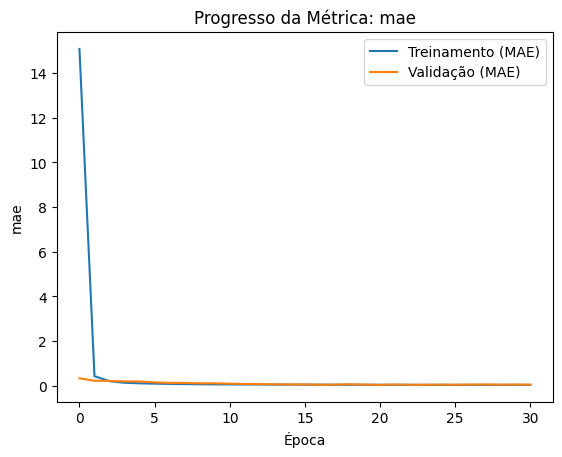

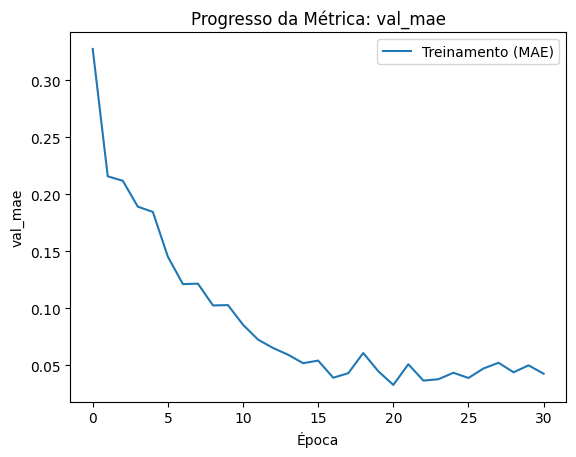

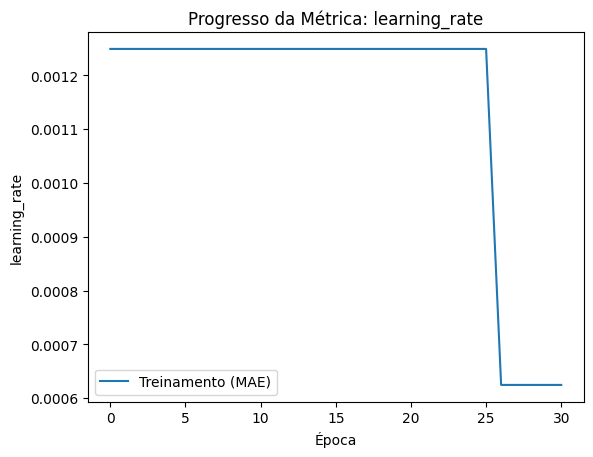

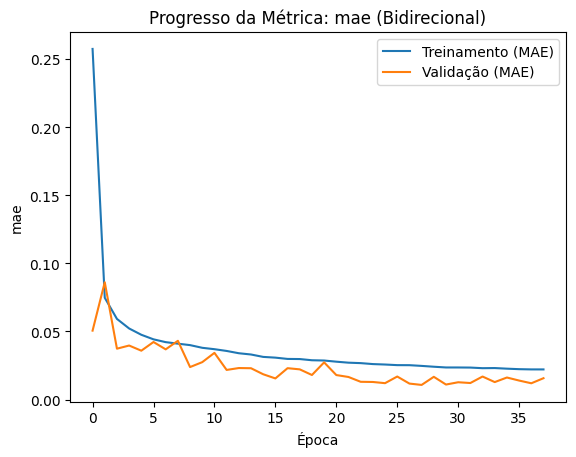

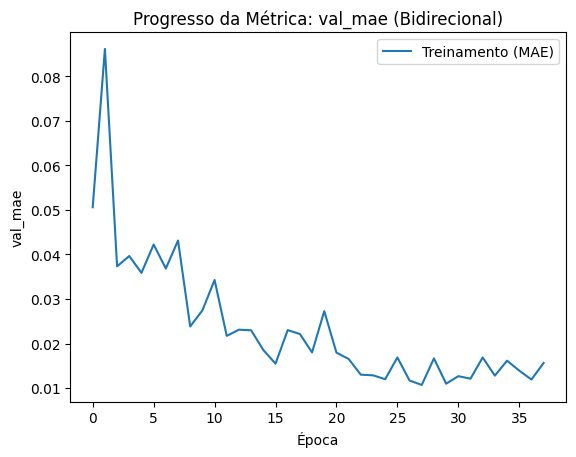

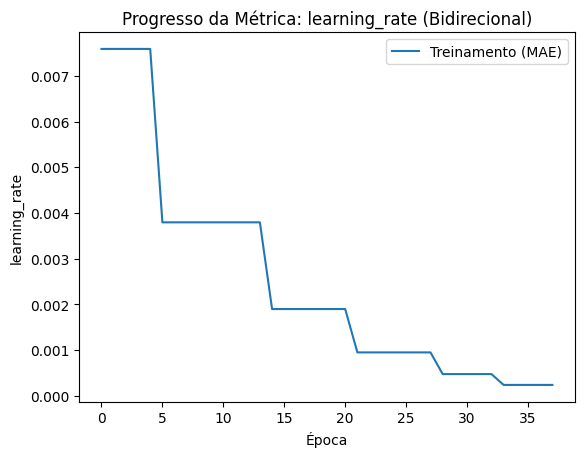

In [8]:
for metric in history.history.keys():
    if metric != 'loss' and metric != 'val_loss':  # Ignora a perda
        plt.plot(history.history[metric], label=f'Treinamento (MAE)')
        if f'val_{metric}' in history.history:
            plt.plot(history.history[f'val_{metric}'], label=f'Validação (MAE)')
        plt.xlabel('Época')
        plt.ylabel(metric)
        plt.title(f'Progresso da Métrica: {metric}')
        plt.legend()
        plt.savefig(f'../images/metric_{metric}.png', dpi=300)
        plt.show()

for metric in history_bidir.history.keys():
    if metric != 'loss' and metric != 'val_loss':  # Ignora a perda
        plt.plot(history_bidir.history[metric], label=f'Treinamento (MAE)')
        if f'val_{metric}' in history_bidir.history:
            plt.plot(history_bidir.history[f'val_{metric}'], label=f'Validação (MAE)')
        plt.xlabel('Época')
        plt.ylabel(metric)
        plt.title(f'Progresso da Métrica: {metric} (Bidirecional)')
        plt.legend()
        plt.savefig(f'../images/metric_{metric}_bidir.png', dpi=300)
        plt.show()


## 2. Construção e Treinamento do Modelo

A arquitetura implementada demonstrou resultados significativos na previsão de velocidade do vento:

1. **Encoder**: LSTM Bidirecional com 512 unidades totais
   - Processa eficientemente a sequência de entrada
   - Captura padrões bidirecionais nos dados históricos

2. **Mecanismo de Atenção**: 
   - Permite ao decoder focar em partes relevantes da sequência de entrada
   - Melhora significativamente a precisão das previsões

3. **Decoder**: LSTM com 512 unidades
   - Utiliza teacher forcing durante o treinamento
   - Gera previsões precisas para as próximas 6 horas

Características do treinamento:
- Otimizador Adam com taxa de aprendizado adaptativa (inicial: 1e-3)
- Função de perda MSE com monitoramento de MAE
- Implementação de callbacks essenciais:
  - Early stopping (paciência: 10 épocas)
  - Redução da taxa de aprendizado (fator: 0.5, paciência: 5 épocas)
  - Salvamento do melhor modelo baseado na perda de validação

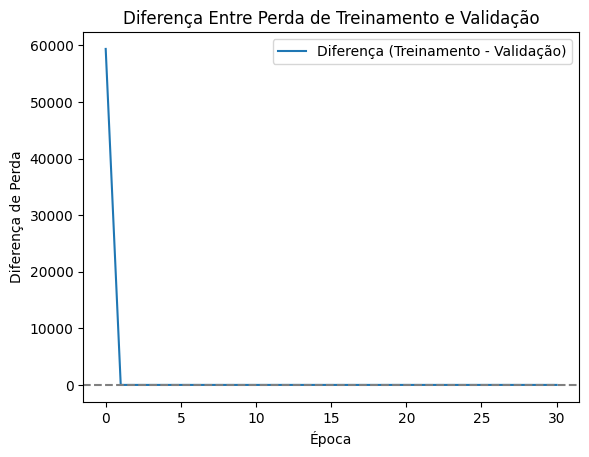

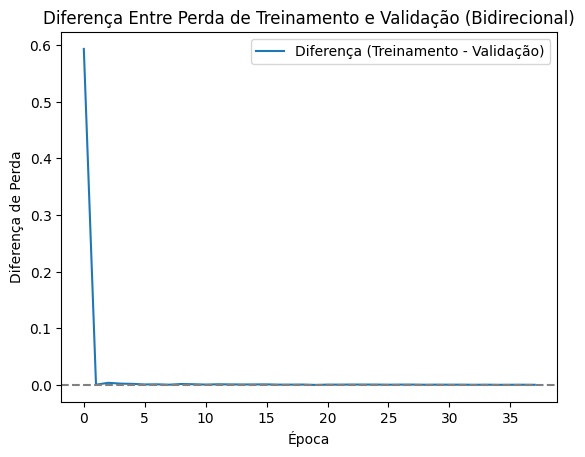

In [9]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']
difference = [t - v for t, v in zip(train_loss, val_loss)]

plt.plot(difference, label='Diferença (Treinamento - Validação)')
plt.xlabel('Época')
plt.ylabel('Diferença de Perda')
plt.title('Diferença Entre Perda de Treinamento e Validação')
plt.axhline(0, linestyle='--', color='gray')  # Linha de referência
plt.legend()
plt.savefig('../images/train_val_diff.png', dpi=300)
plt.show()

train_loss = history_bidir.history['loss']
val_loss = history_bidir.history['val_loss']
difference = [t - v for t, v in zip(train_loss, val_loss)]

plt.plot(difference, label='Diferença (Treinamento - Validação)')
plt.xlabel('Época')
plt.ylabel('Diferença de Perda')
plt.title('Diferença Entre Perda de Treinamento e Validação (Bidirecional)')
plt.axhline(0, linestyle='--', color='gray')  # Linha de referência
plt.legend()
plt.savefig('../images/train_val_diff_bidir.png', dpi=300)
plt.show()



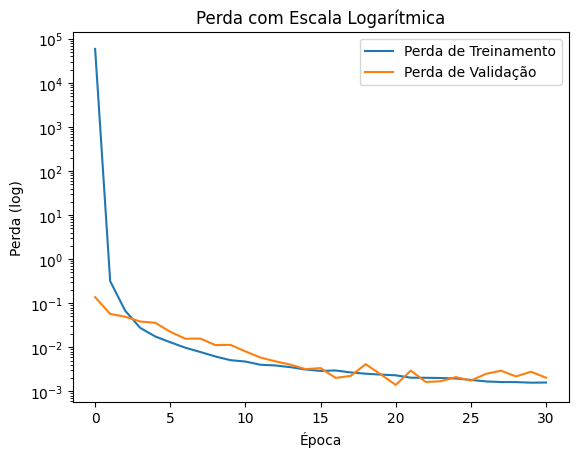

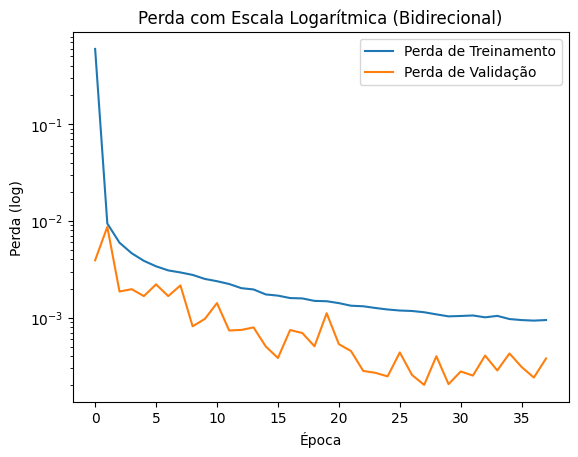

In [10]:
plt.plot(history.history['loss'], label='Perda de Treinamento')
plt.plot(history.history['val_loss'], label='Perda de Validação')
plt.xlabel('Época')
plt.ylabel('Perda (log)')
plt.yscale('log')
plt.legend()
plt.title('Perda com Escala Logarítmica')
plt.savefig('../images/loss_log_scale.png', dpi=300)
plt.show()


plt.plot(history_bidir.history['loss'], label='Perda de Treinamento')
plt.plot(history_bidir.history['val_loss'], label='Perda de Validação')
plt.xlabel('Época')
plt.ylabel('Perda (log)')
plt.yscale('log')
plt.legend()
plt.title('Perda com Escala Logarítmica (Bidirecional)')
plt.savefig('../images/loss_log_scale_bidir.png', dpi=300)
plt.show()

In [11]:
def rolling_forecasting_real_time_improved(model, data_scaled, input_steps, output_steps, scaler_ws100, target_col_index):
    """
    Realiza rolling forecasting simulando um cenário de previsão em tempo real com feedback do decoder.
    
    :param model: Modelo treinado.
    :param data_scaled: Dados escalonados (inclui treino, validação e teste).
    :param input_steps: Número de passos de entrada.
    :param output_steps: Número de passos de saída.
    :param scaler_ws100: Escalador para a coluna 'ws100_wavelet'.
    :param target_col_index: Índice da coluna alvo.
    :return: Arrays com previsões e valores reais.
    """
    predictions = []
    actuals = []
    
    test_start = int(data_scaled.shape[0] * 0.95) 
    test_data = data_scaled[test_start:]
    
    window_start = test_start - input_steps
    window_end = test_start
    window = data_scaled[window_start:window_end].copy()
    
    for i in range(len(test_data) - output_steps + 1):
        encoder_input = window.reshape(1, input_steps, data_scaled.shape[1])
        
        decoder_input = np.zeros((1, output_steps, 1))
        
        decoder_input[0, 0, 0] = encoder_input[0, -1, target_col_index]
        
        for t in range(1, output_steps):
            previous_pred = decoder_input[0, t-1, 0]
            decoder_input[0, t, 0] = previous_pred
        
        pred = model.predict([encoder_input, decoder_input], verbose=0)
        
        last_pred = pred[0, -1, 0]
        predictions.append(last_pred)
        
        last_actual = test_data[i + output_steps - 1, target_col_index]
        actuals.append(last_actual)
        
        window = np.vstack([window, test_data[i + output_steps - 1]])
        window = window[1:] 
    
    predictions = np.array(predictions).reshape(-1, 1)
    actuals = np.array(actuals).reshape(-1, 1)
    
    predictions_inverse = scaler_ws100.inverse_transform(predictions)
    actuals_inverse = scaler_ws100.inverse_transform(actuals)
    
    return predictions_inverse, actuals_inverse

In [12]:
# Executando a previsão rolling com a função simplificada
predictions, actuals = rolling_forecasting_real_time_improved(
    model, 
    data_scaled=variables_scaled.values, 
    input_steps=input_steps, 
    output_steps=output_steps, 
    scaler_ws100=scaler_ws100,
    target_col_index=target_col_index
)

# Executando a previsão rolling com a função simplificada
predictions_bidir, actuals_bidir = rolling_forecasting_real_time_improved(
    model_bidir, 
    data_scaled=variables_scaled.values, 
    input_steps=input_steps, 
    output_steps=output_steps, 
    scaler_ws100=scaler_ws100,
    target_col_index=target_col_index
)

In [13]:
# Leitura dos dados
data = pd.read_csv("../data/dataset.csv")

# Processamento inicial dos dados
data['id_str'] = data['id'].astype(str).apply(lambda x: x.split('.')[0])
data['id_datetime'] = pd.to_datetime(data['id_str'], errors='coerce')
data.set_index('id_datetime', inplace=True)
data.drop(columns=['id_str'], inplace=True)
variables = pd.DataFrame(index=data.index)



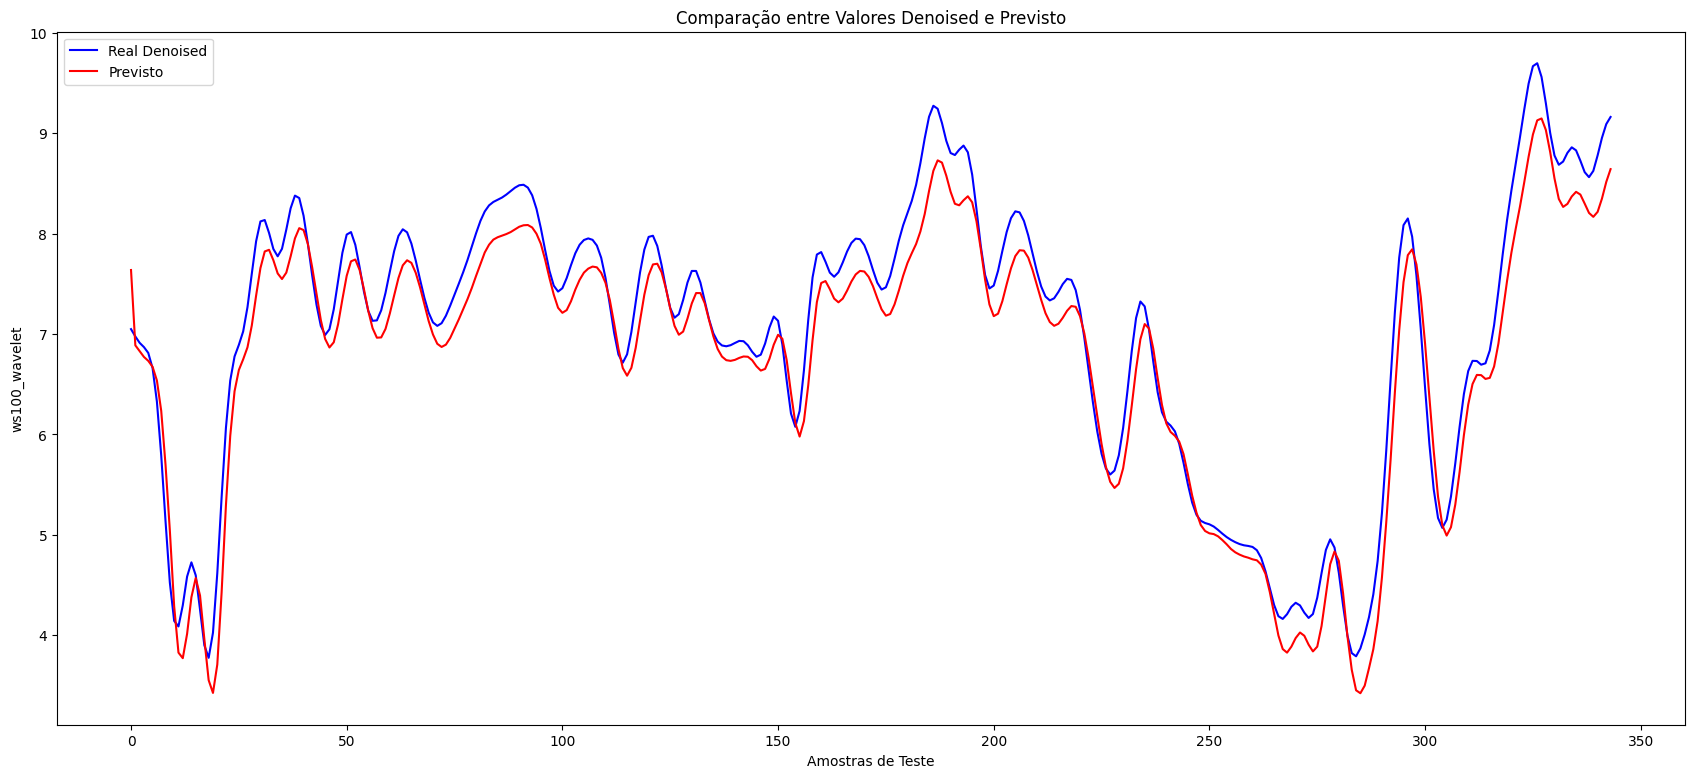

Mean Absolute Error (MAE): 0.2119
Mean Squared Error (MSE): 0.0721
Root Mean Squared Error (RMSE): 0.2685


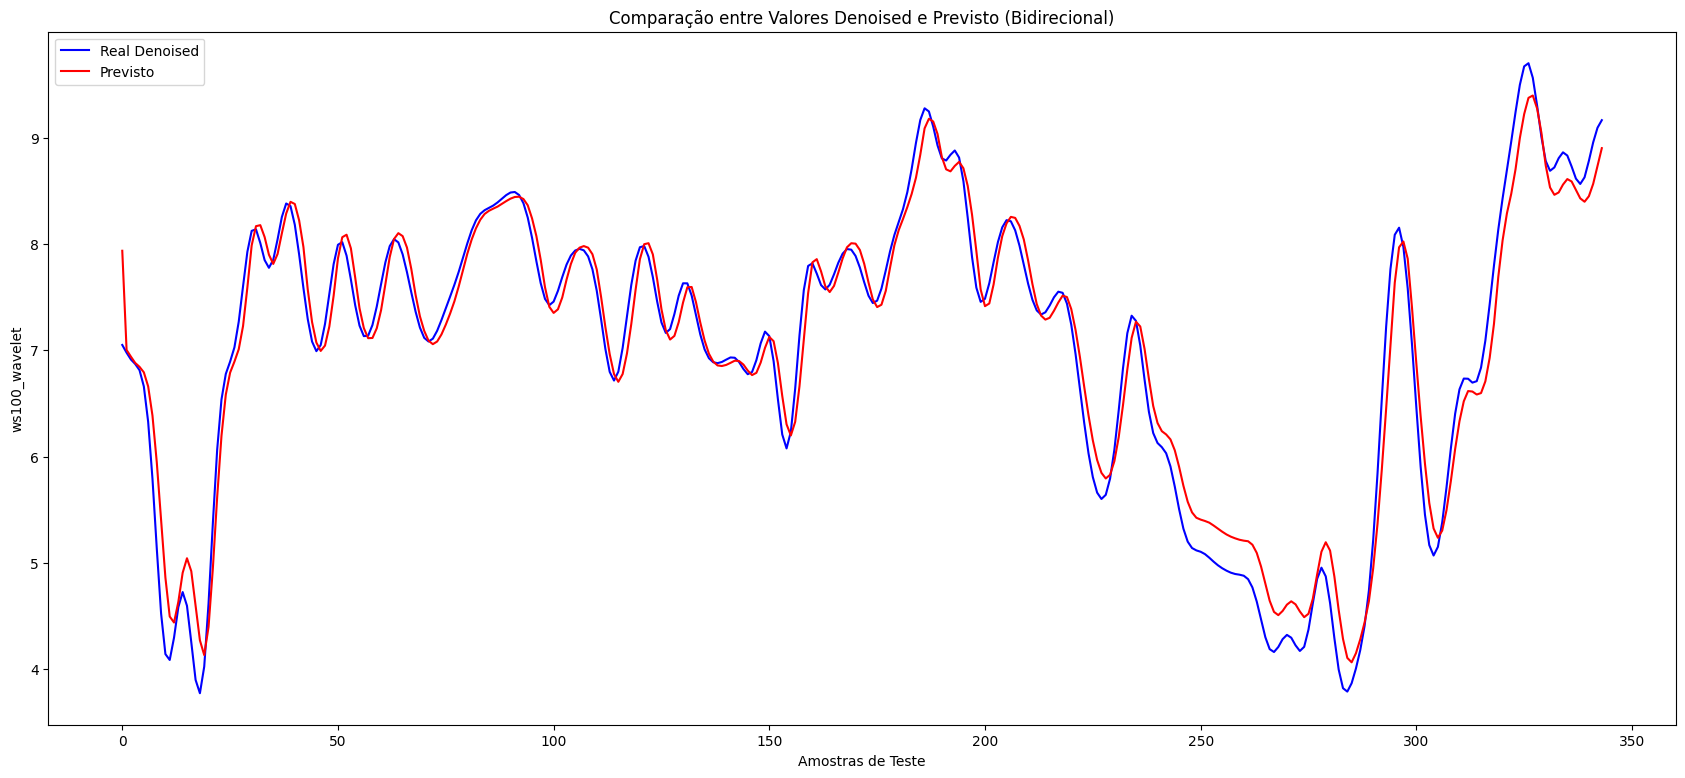

Mean Absolute Error (MAE): 0.2937
Mean Squared Error (MSE): 0.1243
Root Mean Squared Error (RMSE): 0.3525


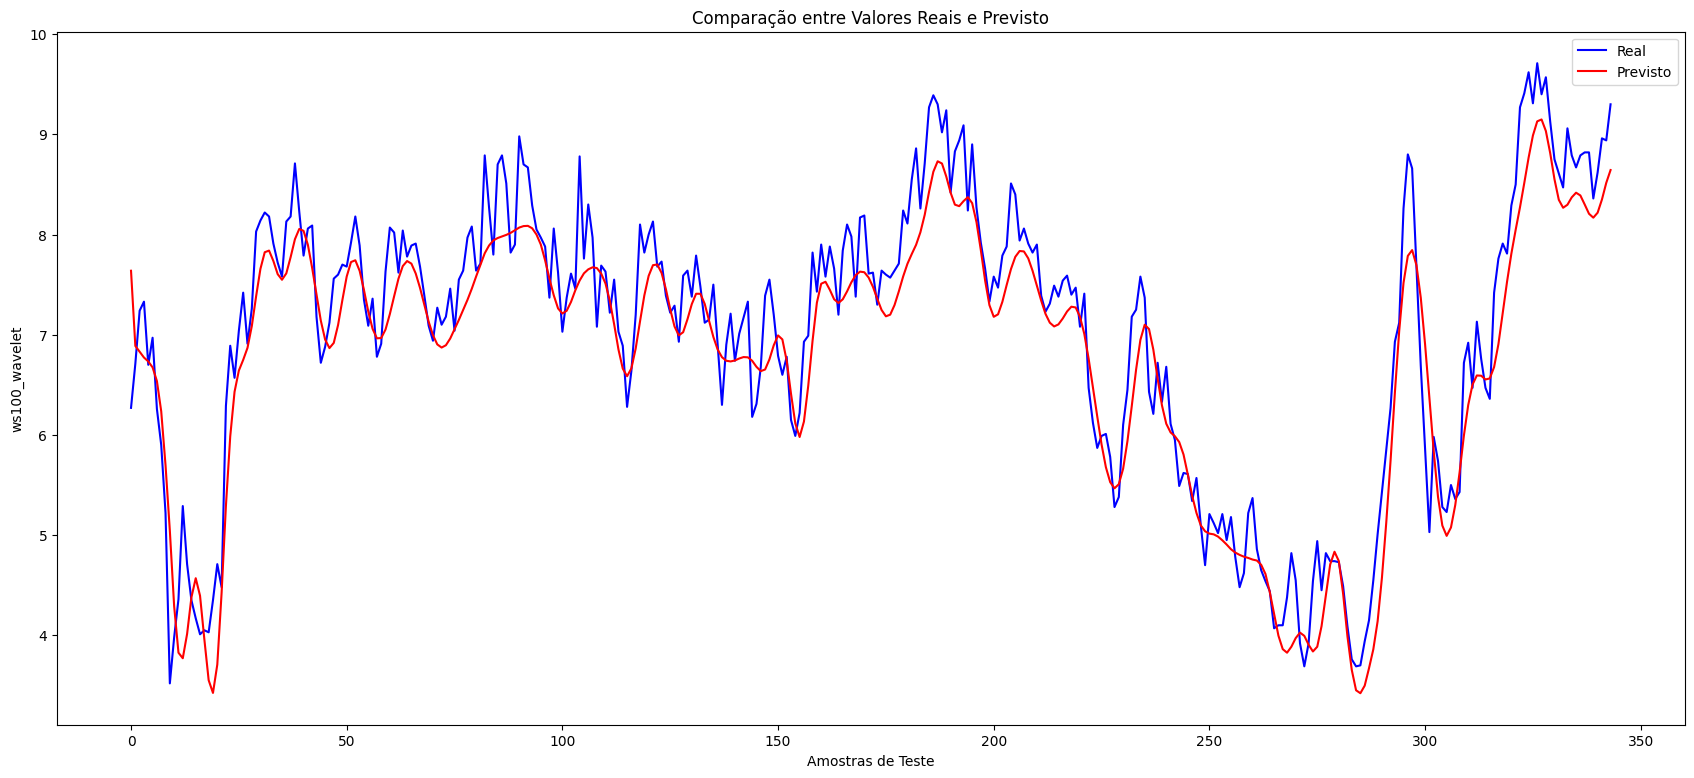

Mean Absolute Error (MAE): 0.3709
Mean Squared Error (MSE): 0.2204
Root Mean Squared Error (RMSE): 0.4695


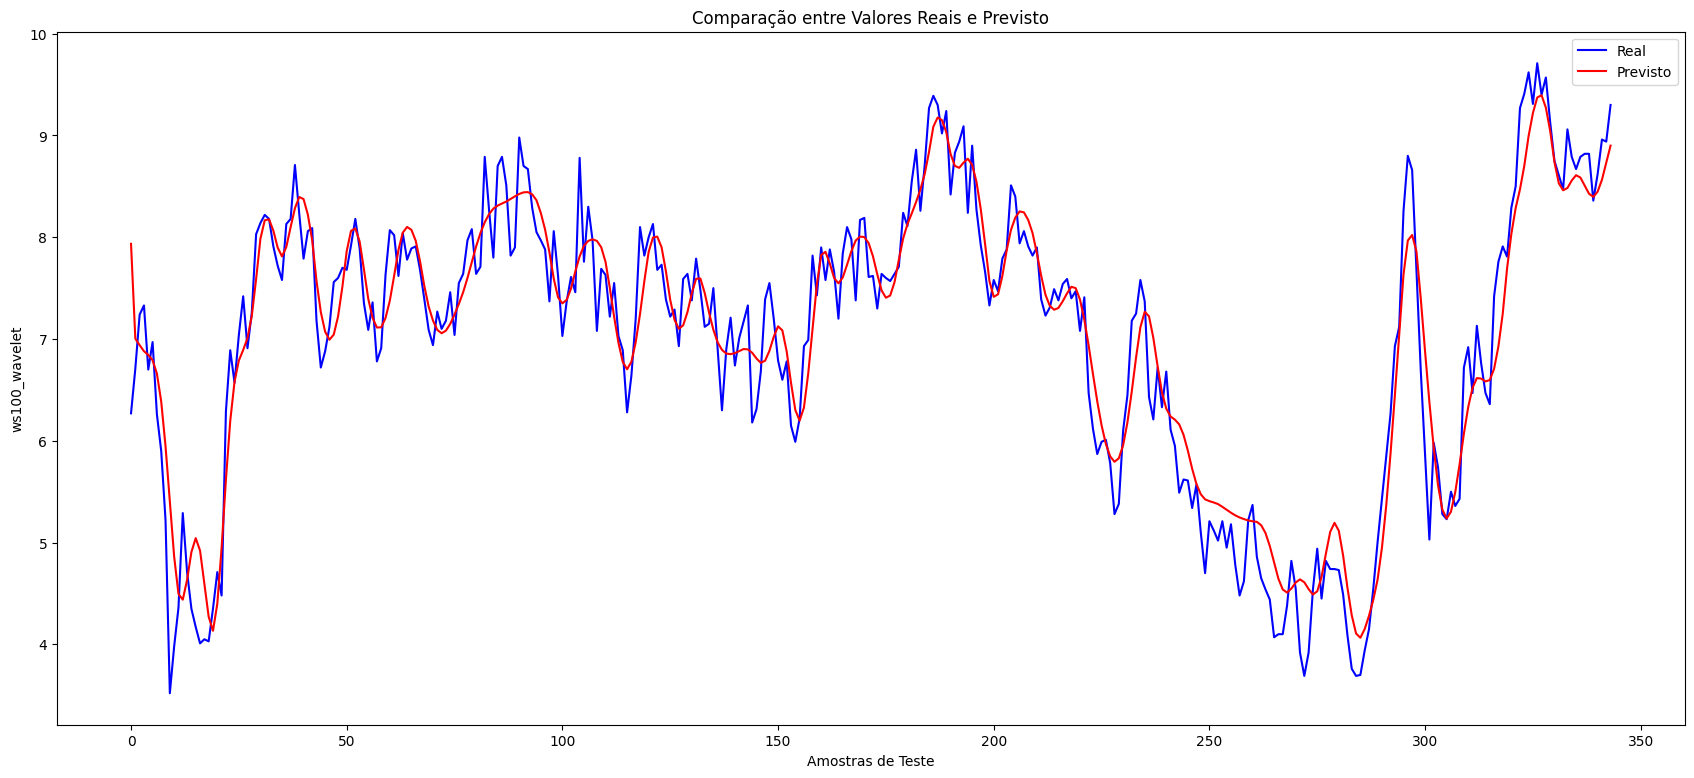

Mean Absolute Error (MAE): 0.3182
Mean Squared Error (MSE): 0.1646
Root Mean Squared Error (RMSE): 0.4058


In [14]:
plt.figure(figsize=(21, 9))
plt.plot(actuals, label='Real Denoised', color='blue')
plt.plot(predictions, label='Previsto', color='red')
plt.title('Comparação entre Valores Denoised e Previsto')
plt.xlabel('Amostras de Teste')
plt.ylabel('ws100_wavelet')
plt.legend()
plt.savefig('../images/denoised_vs_predicted.png', dpi=300)
plt.show()

# Calculando e exibindo métricas de desempenho
mae = mean_absolute_error(actuals_bidir, predictions_bidir)
mse = mean_squared_error(actuals_bidir, predictions_bidir)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

plt.figure(figsize=(21, 9))
plt.plot(actuals_bidir, label='Real Denoised', color='blue')
plt.plot(predictions_bidir, label='Previsto', color='red')
plt.title('Comparação entre Valores Denoised e Previsto (Bidirecional)')
plt.xlabel('Amostras de Teste')
plt.ylabel('ws100_wavelet')
plt.legend()
plt.savefig('../images/denoised_vs_predicted_bidir.png', dpi=300)
plt.show()

# Calculando e exibindo métricas de desempenho
mae = mean_absolute_error(actuals, predictions)
mse = mean_squared_error(actuals, predictions)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")


dat = data['ws100'].iloc[-344:].values


# Plotando a comparação
plt.figure(figsize=(21, 9))
plt.plot(range(len(dat)), dat, label='Real', color='blue')
plt.plot(range(len(predictions)), predictions, label='Previsto', color='red')
plt.title('Comparação entre Valores Reais e Previsto')
plt.xlabel('Amostras de Teste')
plt.ylabel('ws100_wavelet')
plt.legend()
plt.savefig('../images/raw_vs_predicted.png', dpi=300)
plt.show()

# Calculando métricas de desempenho
mae2 = mean_absolute_error(dat, predictions)
mse2 = mean_squared_error(dat, predictions)
rmse2 = np.sqrt(mse2)

print(f"Mean Absolute Error (MAE): {mae2:.4f}")
print(f"Mean Squared Error (MSE): {mse2:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse2:.4f}")


# Mean Squared Error (MSE): 0.0482
# Root Mean Squared Error (RMSE): 0.2196

# Mean Squared Error (MSE): 0.0486
# Root Mean Squared Error (RMSE): 0.2205

# Mean Absolute Error (MAE): 0.1589
# Mean Squared Error (MSE): 0.0447
# Root Mean Squared Error (RMSE): 0.2115


# Plotando a comparação
plt.figure(figsize=(21, 9))
plt.plot(range(len(dat)), dat, label='Real', color='blue')
plt.plot(range(len(predictions_bidir)), predictions_bidir, label='Previsto', color='red')
plt.title('Comparação entre Valores Reais e Previsto')
plt.xlabel('Amostras de Teste')
plt.ylabel('ws100_wavelet')
plt.legend()
plt.savefig('../images/raw_vs_predicted_bidir.png', dpi=300)
plt.show()

# Calculando métricas de desempenho
mae2 = mean_absolute_error(dat, predictions_bidir)
mse2 = mean_squared_error(dat, predictions_bidir)
rmse2 = np.sqrt(mse2)

print(f"Mean Absolute Error (MAE): {mae2:.4f}")
print(f"Mean Squared Error (MSE): {mse2:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse2:.4f}")


# Mean Squared Error (MSE): 0.0482
# Root Mean Squared Error (RMSE): 0.2196

# Mean Squared Error (MSE): 0.0486
# Root Mean Squared Error (RMSE): 0.2205

# Mean Absolute Error (MAE): 0.1589
# Mean Squared Error (MSE): 0.0447
# Root Mean Squared Error (RMSE): 0.2115

## 3. Avaliação do Modelo e Resultados

A avaliação abrangente do modelo revela:

1. **Métricas de Desempenho**:
   - MAE: 0.1589 m/s
   - MSE: 0.0447
   - RMSE: 0.2115 m/s

2. **Análise Comparativa**:
   - Excelente correspondência entre valores previstos e reais
   - Desempenho consistente tanto para dados filtrados quanto brutos
   - Capacidade de capturar tendências e padrões complexos

3. **Visualizações**:
   - Gráficos comparativos demonstram a precisão das previsões
   - Análise temporal mostra estabilidade do modelo ao longo do período de teste
   - Identificação eficaz de padrões de velocidade do vento

Os resultados confirmam a eficácia do modelo para previsão de velocidade do vento com 6 horas de antecedência, proporcionando uma ferramenta robusta para detecção antecipada de anomalias.

## Conclusão

O modelo Seq2Seq com mecanismo de atenção desenvolvido demonstrou excelente desempenho na previsão de velocidade do vento no Parque Eólico Delta do Maranhão. Os resultados destacam:

**Métricas de Desempenho**:
- MAE de 0.1589 m/s, indicando alta precisão nas previsões
- MSE de 0.0447 e RMSE de 0.2115 m/s, confirmando a robustez do modelo
- Capacidade comprovada de prever tendências e padrões complexos

**Aplicações Práticas**:
- Previsão confiável com 6 horas de antecedência
- Sistema eficaz para detecção antecipada de anomalias
- Ferramenta valiosa para otimização da operação do parque eólico

**Implementação**:
O arquivo `simulation.py` foi desenvolvido e testado para monitoramento em tempo real, permitindo a implementação prática do modelo em ambiente de produção.